In [1]:
import pandas as pd
import numpy as np
import requests
import zipfile
import os
import io
import re

In [2]:
RAW_DIR = 'raw'
OUT_DIR = 'datasets'
os.makedirs(RAW_DIR, exist_ok = True)
os.makedirs(OUT_DIR, exist_ok = True)


In [3]:
FF_URL = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp'

def ff_data(zip_name: str) -> str:
    path = os.path.join(RAW_DIR, zip_name)
    if not os.path.exists(path):
        r = requests.get(f'{FF_URL}/{zip_name}', headers={"User-Agent": "Mozilla/5.0"})
        with open(path, 'wb') as f:
            f.write(r.content)

    with zipfile.ZipFile(path, 'r') as z:
        csv_name = [f for f in z.namelist() if f.endswith(('.csv', '.txt'))][0]
        return z.read(csv_name).decode("latin-1")


In [4]:
#Downloading the FF_Factors Data (Daily)
FF_factors = ff_data('F-F_Research_Data_5_Factors_2x3_daily_CSV.zip')

In [5]:
from io import StringIO
FF_factors = pd.read_csv(StringIO(FF_factors), skiprows = 4, skipfooter = 2, engine = 'python', na_values=[-99.99, -999])
FF_factors = FF_factors.rename(columns = {FF_factors.columns[0]: 'Date'})
FF_factors['Date'] = pd.to_datetime(FF_factors["Date"].astype(str).str.strip(), format = '%Y%m%d')
FF_factors

,Date,Mkt-RF,SMB,HML,RMW,CMA,RF
0,1963-07-01,-0.67,0.00,-0.33,-0.01,0.16,0.01
1,1963-07-02,0.79,-0.26,0.26,-0.07,-0.20,0.01
2,1963-07-03,0.63,-0.17,-0.10,0.18,-0.34,0.01
3,1963-07-05,0.40,0.08,-0.27,0.09,-0.34,0.01
4,1963-07-08,-0.63,0.04,-0.18,-0.29,0.14,0.01
...,...,...,...,...,...,...,...
15892,2026-08-25,0.31,0.00,-0.33,-0.88,-0.30,0.01
15893,2026-08-26,-0.06,-0.13,0.20,0.26,0.46,0.01
15894,2026-08-27,0.72,-0.17,-1.14,-0.78,-0.89,0.01
15895,2026-08-28,-0.34,-0.37,0.28,1.66,0.49,0.01


In [6]:
FF_mom = ff_data('F-F_Momentum_Factor_daily_CSV.zip')
FF_mom = pd.read_csv(StringIO(FF_mom), skiprows = 13, skipfooter = 2, engine = 'python', na_values=[-99.99, -999])
FF_mom = FF_mom.rename(columns = {FF_mom.columns[0]: 'Date'})
FF_mom['Date'] = pd.to_datetime(FF_mom["Date"].astype(str).str.strip(), format = '%Y%m%d')
FF_mom.head(10)

,Date,Mom
0,1926-11-03,0.55
1,1926-11-04,-0.51
2,1926-11-05,1.17
3,1926-11-06,-0.03
4,1926-11-08,-0.01
5,1926-11-09,0.12
6,1926-11-10,0.28
7,1926-11-11,-0.94
8,1926-11-12,-0.34
9,1926-11-13,0.40


In [7]:
FF_industry = ff_data('10_Industry_Portfolios_daily_CSV.zip')
FF_industry = pd.read_csv(StringIO(FF_industry), skiprows = 9, engine = 'python', nrows = 26319,na_values=[-99.99, -999])
FF_industry.columns.tolist()
FF_industry = FF_industry.rename(columns = {FF_industry.columns[0]: 'Date'})
FF_industry['Date'] = pd.to_datetime(FF_industry["Date"], format = '%Y%m%d')

In [8]:
for df in (FF_factors, FF_mom, FF_industry):
    df.columns = df.columns.str.strip()
industry_columns = [c for c in FF_industry if  c != 'Date']

In [9]:
ff = FF_factors.merge(FF_mom, on = 'Date', how = 'inner').merge(FF_industry, on = 'Date', how = 'inner').sort_values('Date').reset_index(drop = True)
ff.head()

,Date,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other
0,1963-07-01,-0.67,0.00,-0.33,-0.01,0.16,0.01,-0.23,-0.31,-0.56,-0.75,-0.83,-1.50,-0.61,-0.35,-0.80,-0.18,-0.68
1,1963-07-02,0.79,-0.26,0.26,-0.07,-0.20,0.01,0.45,0.48,0.94,0.70,0.96,1.92,0.90,0.43,0.67,0.48,0.70
2,1963-07-03,0.63,-0.17,-0.10,0.18,-0.34,0.01,0.39,0.56,0.47,0.58,1.02,0.94,0.76,0.84,0.72,0.12,0.57
3,1963-07-05,0.40,0.08,-0.27,0.09,-0.34,0.01,0.06,0.23,0.43,0.38,0.89,0.62,0.25,0.08,0.74,0.13,0.21
4,1963-07-08,-0.63,0.04,-0.18,-0.29,0.14,0.01,-0.45,-0.29,-0.96,-0.60,-0.79,-1.52,-0.62,-0.08,-0.52,0.02,-0.74


In [10]:
num = [c for c in ff.columns if c != "Date"]
ff[num] = ff[num] / 100.0
# 4. Industries are TOTAL returns. Subtract RF to make them excess.
ff[industry_columns] = ff[industry_columns].sub(ff["RF"], axis=0)
print(ff[['Mkt-RF','RF','HiTec']].describe())
print(ff['Mkt-RF'].std())       # expect ~0.01
print(ff['Mkt-RF'].min())
ff.to_csv("ff_merged.csv", index=False)

             Mkt-RF            RF         HiTec
count  15897.000000  15897.000000  15897.000000
mean       0.000291      0.000172      0.000372
std        0.010212      0.000127      0.014325
min       -0.174400      0.000000     -0.200000
25%       -0.004200      0.000100     -0.006600
50%        0.000500      0.000200      0.000600
75%        0.005100      0.000200      0.007400
max        0.113600      0.000600      0.159900
0.010212157941257337
-0.1744


In [11]:
assert abs(ff['Mkt-RF'].min() + 0.1744) < 0.001      # Black Monday
assert 0.009 < ff['Mkt-RF'].std() < 0.012
assert ff['Date'].is_unique and ff['Date'].is_monotonic_increasing

In [12]:
long = (ff.drop(columns=["RF"]))
long = long.melt(id_vars = 'Date', var_name = 'series', value_name = 'ret').dropna(subset=["ret"])


In [13]:
long["month"] = long["Date"].dt.to_period("M")
long

,Date,series,ret,month
0,1963-07-01,Mkt-RF,-0.0067,1963-07
1,1963-07-02,Mkt-RF,0.0079,1963-07
2,1963-07-03,Mkt-RF,0.0063,1963-07
3,1963-07-05,Mkt-RF,0.0040,1963-07
4,1963-07-08,Mkt-RF,-0.0063,1963-07
...,...,...,...,...
254347,2026-08-25,Other,0.0021,2026-08
254348,2026-08-26,Other,-0.0015,2026-08
254349,2026-08-27,Other,-0.0063,2026-08
254350,2026-08-28,Other,0.0006,2026-08


In [14]:
# 3. Collapse days to months, per series
monthly = (long.groupby(["series", "month"])["ret"]
               .agg(ret_m = lambda x: np.prod(1 + x.values) - 1,
                    rv    = lambda x: np.sum(x.values ** 2),
                    n_days = "size")
               .reset_index())
monthly.head()

,series,month,ret_m,rv,n_days
0,CMA,1963-07,-0.011779,0.000098,22
1,CMA,1963-08,-0.003525,0.000063,22
2,CMA,1963-09,0.001667,0.000069,20
3,CMA,1963-10,-0.021471,0.000208,23
4,CMA,1963-11,0.022234,0.000219,18


In [15]:
# 4. Last month's RV, shifted WITHIN each series
monthly["rv_lag1"] = monthly.groupby("series")["rv"].shift(1)

# 5. Flag partial months, add a timestamp for later merges
monthly["incomplete"] = monthly["n_days"] < 15
monthly["month_end"]  = monthly["month"].dt.to_timestamp("M")

In [16]:
# Right size: 16 series x ~759 months
print(monthly.shape, monthly["series"].nunique())

# rv_lag1 really is the previous month, within series
one = monthly[monthly.series == "Mkt-RF"].reset_index(drop=True)
assert np.allclose(one.rv.values[:-1], one.rv_lag1.values[1:])

# Implied vol from RV should match vol from daily returns
print(np.sqrt(one.rv.mean() * 12))            # expect ~0.16
print(ff["Mkt-RF"].std() * np.sqrt(252))      # expect ~0.16

# First month of every series has no lag
first_rows = monthly.sort_values(["series", "month"]).groupby("series").head(1)
assert first_rows["rv_lag1"].isna().all()

(12128, 8) 16
0.1620666549085449
0.16211298157128162


In [17]:
monthly.to_csv('monthly_returns_rv.csv', index=False)
long.to_csv('ff_long.csv', index=False)
monthly.to_parquet("ff_monthly_baselinedata.parquet", index=False)
long.to_parquet("ff_daily_garchdata.parquet", index=False)

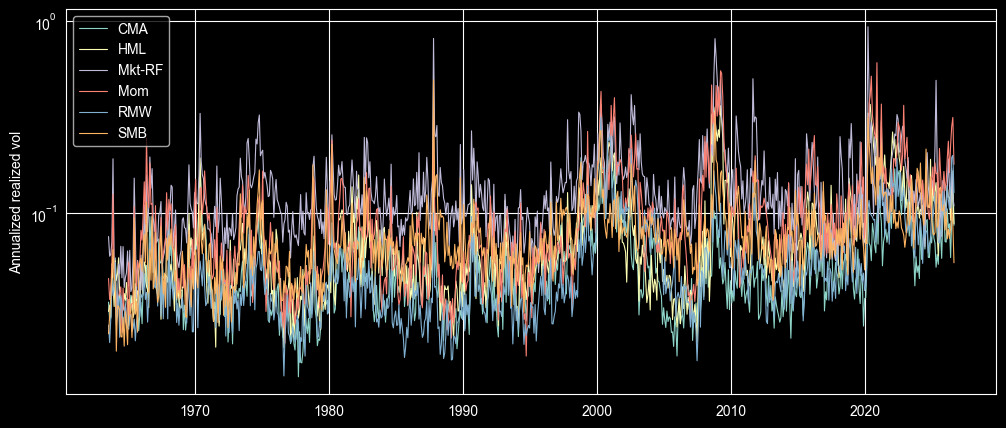

In [18]:
import matplotlib.pyplot as plt
factors = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom"]
f = monthly[monthly.series.isin(factors)].copy()
f["vol"] = np.sqrt(12 * f["rv"])


fig, ax = plt.subplots(figsize=(12, 5))
for name, g in f.groupby("series"):
    ax.plot(g["month_end"], g["vol"], label=name, lw=0.8)
ax.set_yscale("log")
ax.set_ylabel("Annualized realized vol")
ax.legend()
plt.show()

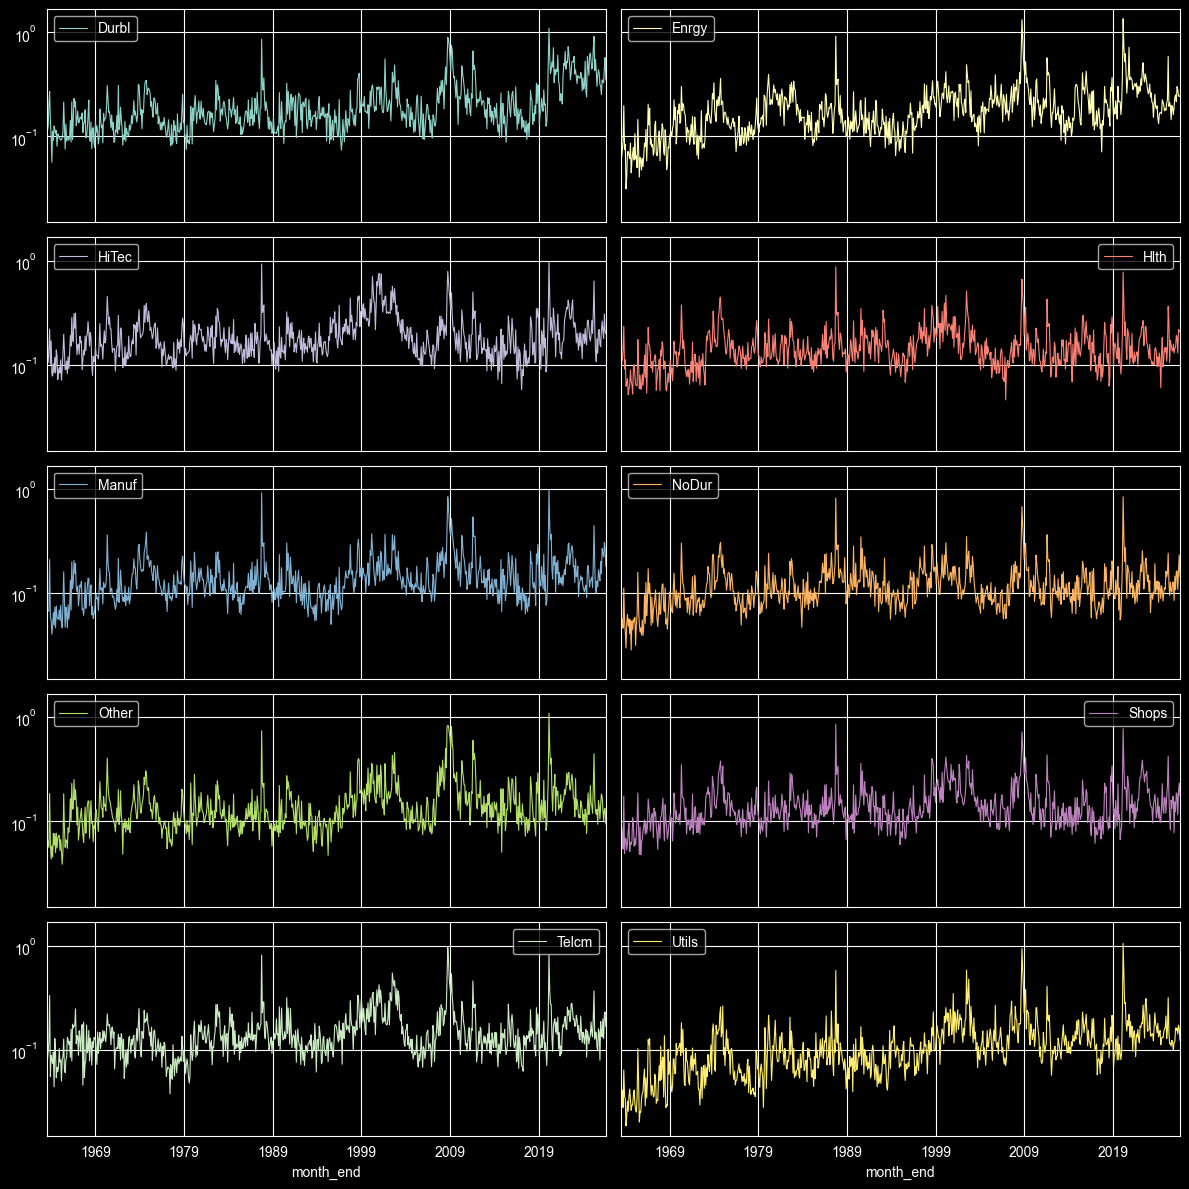

In [19]:
industries = [s for s in monthly.series.unique() if s not in factors]

ind = monthly[monthly.series.isin(industries)].copy()
ind["vol"] = np.sqrt(12 * ind["rv"])

wide_ind = ind.pivot(index="month_end", columns="series", values="vol")
wide_ind.plot(subplots=True, layout=(5, 2), sharex=True, sharey=True,
              logy=True, figsize=(12, 12), lw=0.8)
plt.tight_layout()